Training: Random Forest Classifier
Training: Basic MLP (Sklearn)
Training: XGBoost Classifier
Training: Single Decision Tree
Training: AdaBoost Classifier
Training: Deep MLP (Keras)
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Training: 1D CNN
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Training: Unsupervised Autoencoder
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

 Model execution time results
- Random Forest: 430.50 seconds
- MLP (Sklearn): 55.48 seconds
- XGBoost: 10.98 seconds
- Single Decision Tree: 19.24 seconds
- AdaBoost: 817.09 seconds
- Deep MLP: 49.80 seconds
- 1D CNN (Keras): 270.69 seconds
- Autoencoder: 10.26 seconds




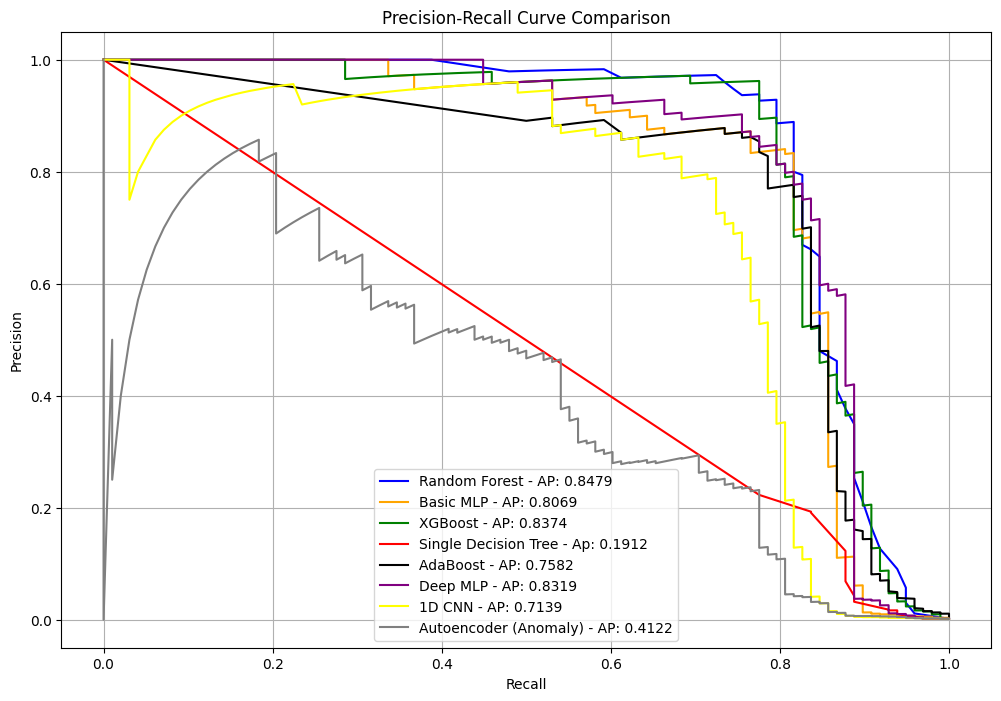

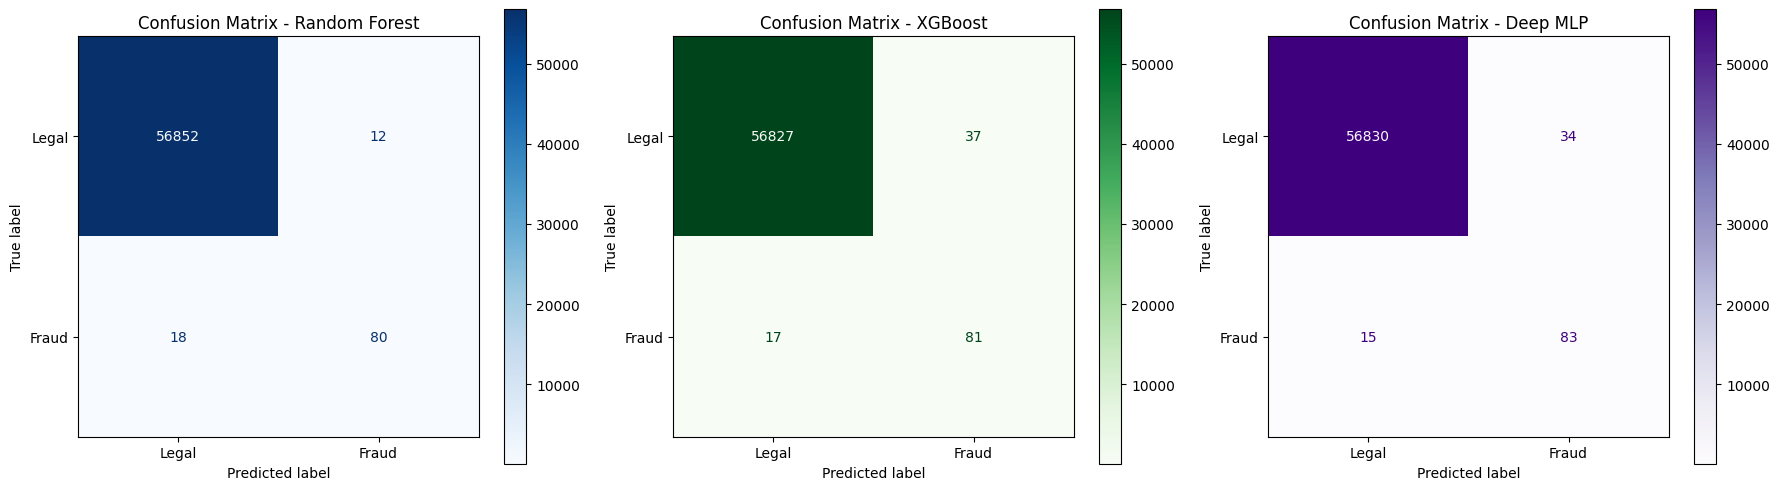

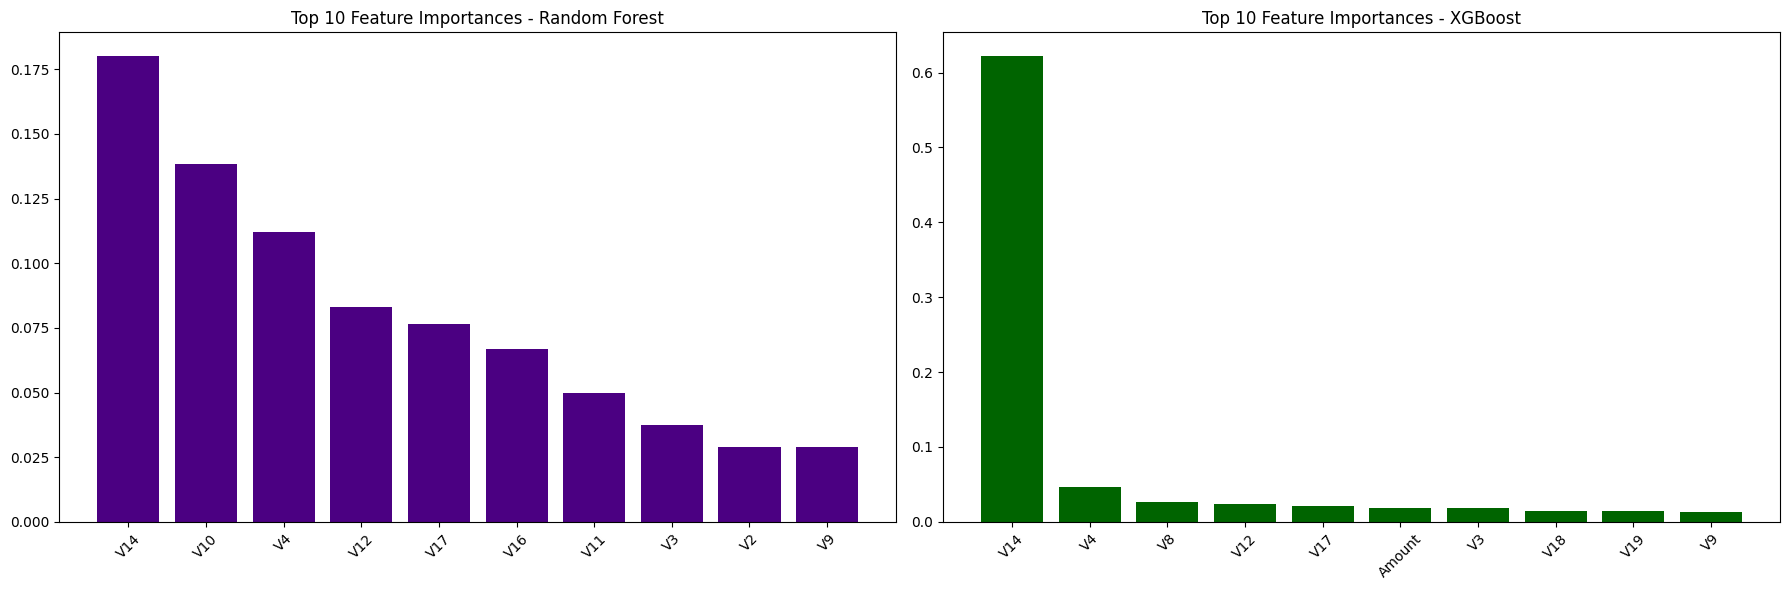

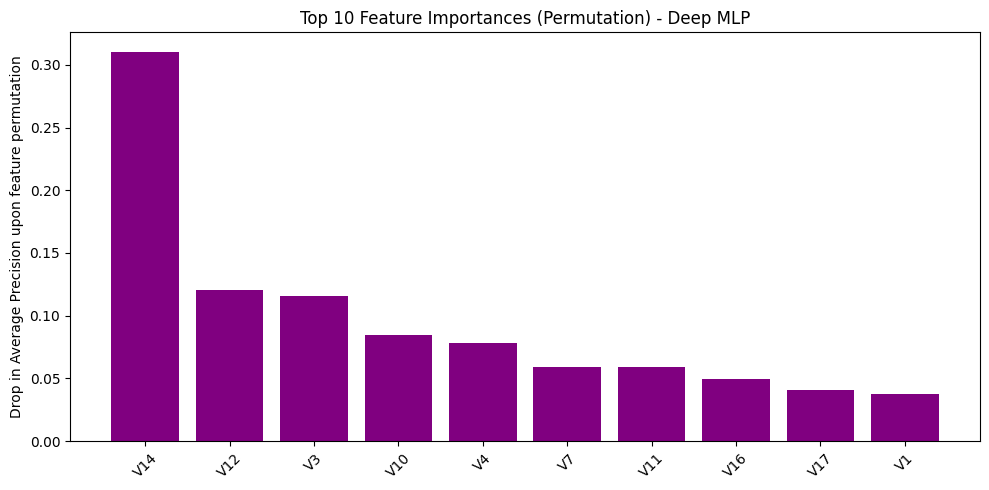

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.inspection import permutation_importance
import time

execution_times = {} #Dictionary to store the training duration of each model
df = pd.read_csv("creditcard.csv") #Loading the credit card fraud dataset

X = df.drop(['Class'], axis=1)
y = df['Class']

scaler = StandardScaler() #Standardize features (Time and Amount) to prevent dominance in distance calculations
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=35, stratify=y
) #Split dataset into training and testing sets with stratified sampling due to high imbalance

X_train_legal = X_train[y_train == 0].values #Clone original training data before SMOTE exclusively for Autoencoder training

smote = SMOTE(random_state=35) #Apply Synthetic Minority Over-sampling Technique (SMOTE) to balance the training data classes
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Training: Random Forest Classifier") #1. Random Forest Classifier
start = time.time()
ensemble_model = RandomForestClassifier(n_estimators=100, random_state=35, n_jobs=-1) #n_jobs=-1 enables full multi-core CPU parallelization
ensemble_model.fit(X_train_smote, y_train_smote)
execution_times['Random Forest'] = time.time() - start
y_proba_ensemble = ensemble_model.predict_proba(X_test)[:, 1]

print("Training: Basic MLP (Sklearn)") #2. Multi-Layer Perceptron (Basic Sklearn implementation)
start = time.time()
nn_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=100, random_state=35)
nn_model.fit(X_train_smote, y_train_smote)
execution_times['MLP (Sklearn)'] = time.time() - start
y_proba_nn = nn_model.predict_proba(X_test)[:, 1]

print("Training: XGBoost Classifier") #3. XGBoost Classifier
start = time.time()
xgb_model = XGBClassifier(random_state=35, n_jobs=-1) #Again using n_jobs=-1 for faster processing
xgb_model.fit(X_train_smote, y_train_smote)
execution_times['XGBoost'] = time.time() - start
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Training: Single Decision Tree") #4. Single Decision Tree
start = time.time()
dt_model = DecisionTreeClassifier(max_depth=5, random_state=35) #Restricting max_depth to prevent overfitting on oversampled data
dt_model.fit(X_train_smote, y_train_smote)
execution_times['Single Decision Tree'] = time.time() - start
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("Training: AdaBoost Classifier") #5. AdaBoost Classifier
start = time.time()
ada_base_tree = DecisionTreeClassifier(max_depth=2, random_state=35) #Using shallow decision trees as weak estimators for sequential boosting
ada_model = AdaBoostClassifier(estimator=ada_base_tree, n_estimators=100, learning_rate=0.1, random_state=35)
ada_model.fit(X_train_smote, y_train_smote)
execution_times['AdaBoost'] = time.time() - start
y_proba_ada = ada_model.predict_proba(X_test)[:, 1]

print("Training: Deep MLP (Keras)") #6. Deep Multi-Layer Perceptron with Regularization
deep_mlp = models.Sequential([
    layers.Input(shape=(X_train_smote.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), #Accelerates training and stabilizes internal covariate shift
    layers.Dropout(0.3),         #Mitigates overfitting by randomly deactivating neurons
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') #Sigmoid function outputs probabilities for binary choice
])
deep_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
start = time.time()
deep_mlp.fit(X_train_smote, y_train_smote, epochs=10, batch_size=1024, verbose=0) #A large batch_size=1024 allows rapid gradient execution on accelerated GPU hardware
execution_times['Deep MLP'] = time.time() - start
y_proba_deep_mlp = deep_mlp.predict(X_test).flatten()

print("Training: 1D CNN") #7. 1D Convolutional Neural Network
X_train_cnn = np.expand_dims(X_train_smote.values, axis=2) #Formatting feature arrays into 3D tensors [samples, features, channels] for 1D convolution layers
X_test_cnn = np.expand_dims(X_test.values, axis=2)
cnn_model = models.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(32, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(), #Condenses structural feature maps into dense representations
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
start = time.time()
cnn_model.fit(X_train_cnn, y_train_smote, epochs=10, batch_size=1024, verbose=0)
execution_times['1D CNN (Keras)'] = time.time() - start
y_proba_cnn = cnn_model.predict(X_test_cnn).flatten()

print("Training: Unsupervised Autoencoder") #8. Unsupervised Autoencoder for Anomaly Detection
#Critical distinction: Trained ONLY on standard/legal transactions (X_train_legal) without SMOTE!
autoencoder = models.Sequential([
    layers.Input(shape=(X_train_legal.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'), #Bottleneck layer squeezing structural representations
    layers.Dense(16, activation='relu'),
    layers.Dense(X_train_legal.shape[1], activation='linear') #Linearly reconstructs features
])
autoencoder.compile(optimizer='adam', loss='mse')
start = time.time()
autoencoder.fit(X_train_legal, X_train_legal, epochs=15, batch_size=1024, verbose=0, validation_split=0.1)
execution_times['Autoencoder'] = time.time() - start
X_test_pred = autoencoder.predict(X_test.values) #Anomaly score is computed as the Mean Squared Error (reconstruction error) on test inputs
reconstruction_error = np.mean(np.power(X_test.values - X_test_pred, 2), axis=1)
scaler_ae = MinMaxScaler() #Normalize anomaly score within a [0, 1] bounds for equitable Precision-Recall comparison
y_proba_ae = scaler_ae.fit_transform(reconstruction_error.reshape(-1, 1)).flatten()

print("\n Model execution time results") #Execution timing metrics report
for name, t in execution_times.items():
  print(f"- {name}: {t:.2f} seconds")
print("\n")

#Metric computation and precision-recall graphing
precision_ens, recall_ens, _ = precision_recall_curve(y_test, y_proba_ensemble)
ap_ens = average_precision_score(y_test, y_proba_ensemble)
precision_nn, recall_nn, _ = precision_recall_curve(y_test, y_proba_nn)
ap_nn = average_precision_score(y_test, y_proba_nn)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
ap_xgb = average_precision_score(y_test, y_proba_xgb)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_proba_dt)
ap_dt = average_precision_score(y_test, y_proba_dt)
precision_ada, recall_ada, _ = precision_recall_curve(y_test, y_proba_ada)
ap_ada = average_precision_score(y_test, y_proba_ada)
precision_dmlp, recall_dmlp, _ = precision_recall_curve(y_test, y_proba_deep_mlp)
ap_dmlp = average_precision_score(y_test, y_proba_deep_mlp)
precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, y_proba_cnn)
ap_cnn = average_precision_score(y_test, y_proba_cnn)
precision_ae, recall_ae, _ = precision_recall_curve(y_test, y_proba_ae)
ap_ae = average_precision_score(y_test, y_proba_ae)

plt.figure(figsize=(12, 8))
plt.plot(recall_ens, precision_ens, label=f'Random Forest - AP: {ap_ens:.4f}', color='blue')
plt.plot(recall_nn, precision_nn, label=f'Basic MLP - AP: {ap_nn:.4f}', color='orange')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost - AP: {ap_xgb:.4f}', color='green')
plt.plot(recall_dt, precision_dt, label=f'Single Decision Tree - Ap: {ap_dt:.4f}', color='red')
plt.plot(recall_ada, precision_ada, label=f'AdaBoost - AP: {ap_ada:.4f}', color='black')
plt.plot(recall_dmlp, precision_dmlp, label=f'Deep MLP - AP: {ap_dmlp:.4f}', color='purple')
plt.plot(recall_cnn, precision_cnn, label=f'1D CNN - AP: {ap_cnn:.4f}', color='yellow')
plt.plot(recall_ae, precision_ae, label=f'Autoencoder (Anomaly) - AP: {ap_ae:.4f}', color='grey')
plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.grid(True)
plt.show()

#Creating confusion matrices
y_pred_xgb = xgb_model.predict(X_test)
y_pred_ensemble = ensemble_model.predict(X_test)
y_pred_dmlp = (y_proba_deep_mlp > 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
disp_rf = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ensemble), display_labels=['Legal', 'Fraud'])
disp_rf.plot(cmap=plt.cm.Blues, ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix - Random Forest')
disp_xgb = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Legal', 'Fraud'])
disp_xgb.plot(cmap=plt.cm.Greens, ax=axes[1], values_format='d')
axes[1].set_title('Confusion Matrix - XGBoost')
disp_dmlp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dmlp), display_labels=['Legal', 'Fraud'])
disp_dmlp.plot(cmap=plt.cm.Purples, ax=axes[2], values_format='d')
axes[2].set_title('Confusion Matrix - Deep MLP')
plt.tight_layout()
plt.show()

#Tree-based feature importance comparison
importances_rf = ensemble_model.feature_importances_
importances_xgb = xgb_model.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]
indices_xgb = np.argsort(importances_xgb)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].set_title("Top 10 Feature Importances - Random Forest")
axes[0].bar(range(10), importances_rf[indices_rf[:10]], align="center", color='indigo')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels([X.columns[i] for i in indices_rf[:10]], rotation=45)
axes[1].set_title("Top 10 Feature Importances - XGBoost")
axes[1].bar(range(10), importances_xgb[indices_xgb[:10]], align="center", color='darkgreen')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([X.columns[i] for i in indices_xgb[:10]], rotation=45)
plt.tight_layout()
plt.show()

#Permutation importance for deep MLP
class KerasDummyEstimator:
    def __init__(self, keras_model):
        self.keras_model = keras_model
        self._estimator_type = "classifier"
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        return self

    def predict_proba(self, X_input):
        proba_class_1 = self.keras_model.predict(X_input, verbose=0).flatten()
        proba_class_0 = 1.0 - proba_class_1
        return np.column_stack((proba_class_0, proba_class_1))

dummy_mlp = KerasDummyEstimator(deep_mlp)
result_mlp = permutation_importance(
    estimator=dummy_mlp,
    X=X_test,
    y=y_test,
    scoring='average_precision',
    n_repeats=3,
    random_state=35,
    n_jobs=1
)
importances_mlp = result_mlp.importances_mean
indices_mlp = np.argsort(importances_mlp)[::-1]
plt.figure(figsize=(10, 5))
plt.title("Top 10 Feature Importances (Permutation) - Deep MLP")
plt.bar(range(10), importances_mlp[indices_mlp[:10]], align="center", color='purple')
plt.xticks(range(10), [X.columns[i] for i in indices_mlp[:10]], rotation=45)
plt.ylabel("Drop in Average Precision upon feature permutation")
plt.tight_layout()
plt.show()